##**Import Libraries and Setup**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

##**Data Loading and Exploration**

In [8]:
df = pd.read_csv('hospital_drug_demand.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (7237, 7)

Columns: ['Date', 'Hospital', 'Drug', 'Action_Type', 'Demand', 'Stock_Level', 'Restock_Amount']

First 5 rows:


,Date,Hospital,Drug,Action_Type,Demand,Stock_Level,Restock_Amount
0,2022-01-01,Central Hospital,Drug_1,Dispense,204,729,0
1,2022-01-01,Central Hospital,Drug_1,Restock,0,525,450
2,2022-01-01,Central Hospital,Drug_2,Dispense,56,771,0
3,2022-01-01,Central Hospital,Drug_3,Dispense,245,742,0
4,2022-01-01,Central Hospital,Drug_4,Dispense,155,565,0


In [9]:

df = df[(df['Action_Type'] == 'Dispense') & (df['Drug'] == 'Drug_1')]
df = df.drop(['Hospital','Drug','Action_Type','Stock_Level','Restock_Amount'],axis = 1)
df.head()
print(df.shape)
df.isna().sum()

(587, 2)


,0
Date,0
Demand,0


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.head(10)

,Date,Demand
0,2022-01-01,204
16,2022-01-02,124
24,2022-01-03,117
40,2022-01-05,132
64,2022-01-08,74
76,2022-01-09,46
87,2022-01-10,209
98,2022-01-11,159
109,2022-01-12,91
117,2022-01-13,82


##**Visualization**

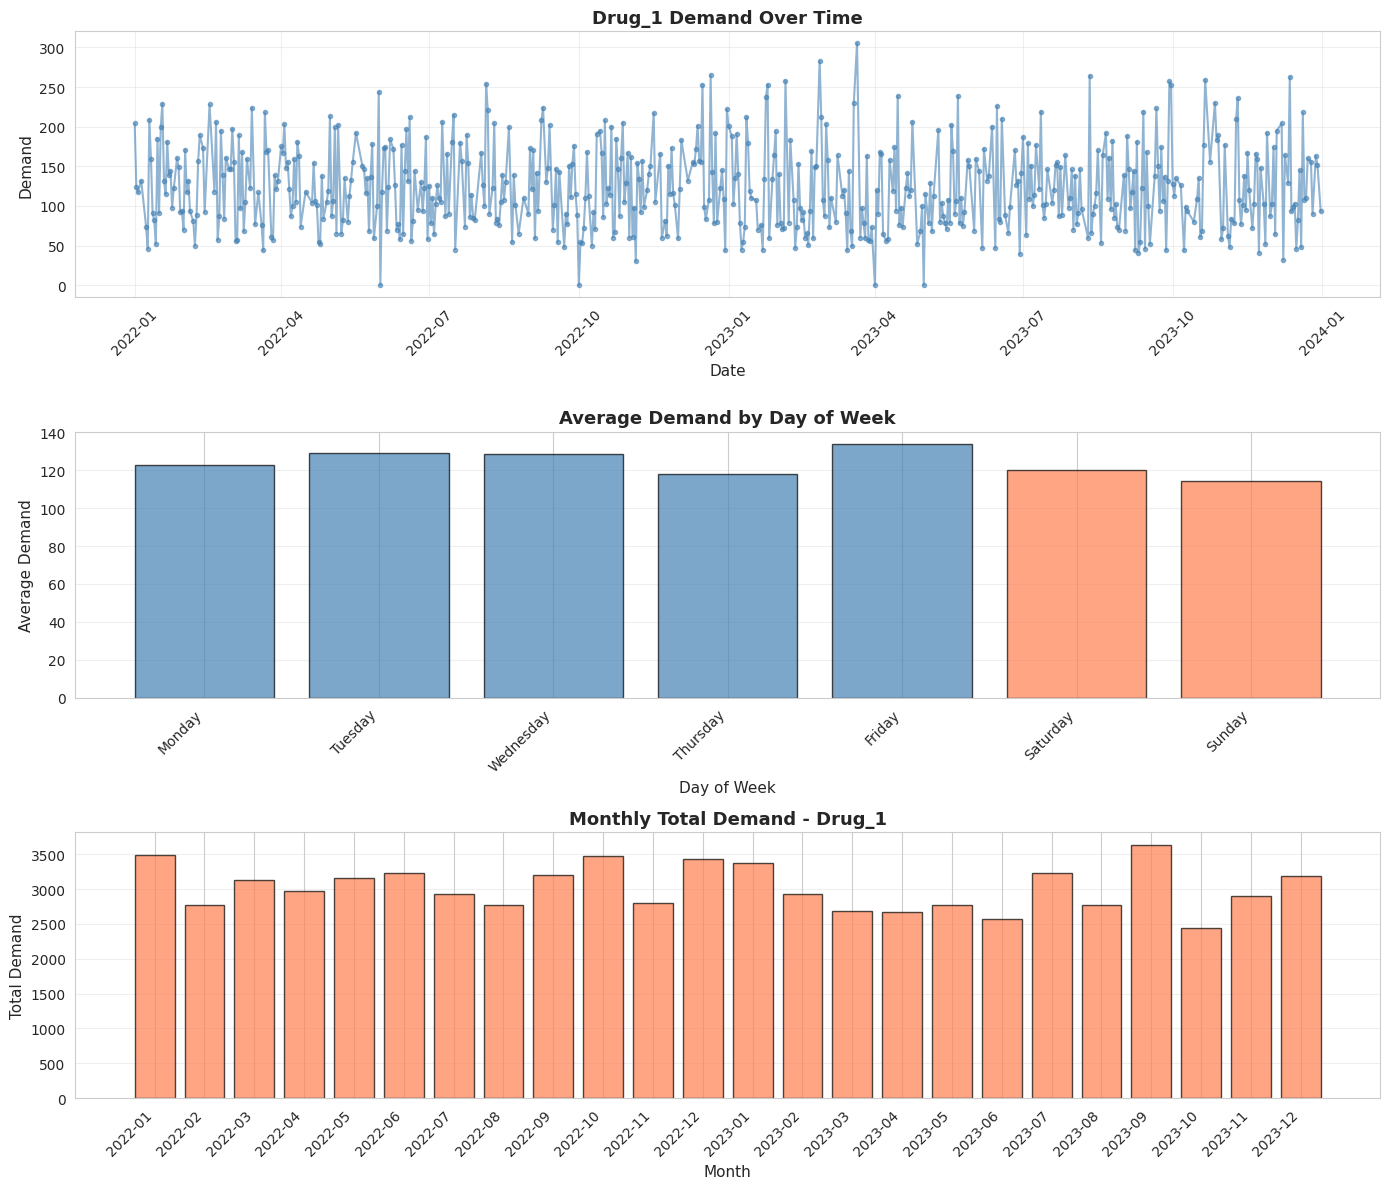


Total records: 587
Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00
Mean demand: 123.58
Std demand: 53.43


In [16]:
# Visualize Drug_1 demand patterns
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Demand over time (line and dot plot)
ax1 = axes[0]
df['Date'] = pd.to_datetime(df['Date'])
ax1.plot(df['Date'], df['Demand'], color='steelblue', alpha=0.6, linewidth=1.5, marker='o', markersize=3)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Demand', fontsize=11)
ax1.set_title('Drug_1 Demand Over Time', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Weekly demand pattern
ax2 = axes[1]
df['day_of_week'] = df['Date'].dt.dayofweek
weekly_avg = df.groupby('day_of_week')['Demand'].mean()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = ['steelblue' if i < 5 else 'coral' for i in range(7)]
ax2.bar(range(7), weekly_avg.values, color=colors, edgecolor='black', alpha=0.7)
ax2.set_xticks(range(7))
ax2.set_xticklabels(days, rotation=45, ha='right')
ax2.set_xlabel('Day of Week', fontsize=11)
ax2.set_ylabel('Average Demand', fontsize=11)
ax2.set_title('Average Demand by Day of Week', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# 3. Monthly demand pattern
ax3 = axes[2]
df['Year_Month'] = df['Date'].dt.to_period('M')
monthly_demand = df.groupby('Year_Month')['Demand'].sum().reset_index()
monthly_demand['Year_Month'] = monthly_demand['Year_Month'].astype(str)
ax3.bar(range(len(monthly_demand)), monthly_demand['Demand'], color='coral', edgecolor='black', alpha=0.7)
ax3.set_xticks(range(len(monthly_demand)))
ax3.set_xticklabels(monthly_demand['Year_Month'], rotation=45, ha='right')
ax3.set_xlabel('Month', fontsize=11)
ax3.set_ylabel('Total Demand', fontsize=11)
ax3.set_title('Monthly Total Demand - Drug_1', fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nTotal records: {len(df)}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Mean demand: {df['Demand'].mean():.2f}")
print(f"Std demand: {df['Demand'].std():.2f}")

##**Feature Engineering**


In [56]:
df = df.drop(['Year_Month'],axis = 1)
df["day_of_week"] = df["Date"].dt.dayofweek
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
df["month"] = df["Date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)


In [50]:
LAGS = [1,7,14,28]
for lag in LAGS:
    df[f'demand_lag_{lag}'] = df['Demand'].shift(lag)


df = df.fillna(0)


In [51]:
# Rolling statistics (7-day window)
df["rolling_mean_7"] = df["Demand"].shift(1).rolling(window=7).mean()
df["rolling_std_7"] = df["Demand"].shift(1).rolling(window=7).std()

In [52]:
# Rolling statistics (14-day window)
df["rolling_mean_14"] = df["Demand"].shift(1).rolling(window=14).mean()
df["rolling_std_14"] = df["Demand"].shift(1).rolling(window=14).std()

In [53]:
#Rolling statistics (28 day window)
df["rolling_mean_28"] = df["Demand"].shift(1).rolling(window=28).mean()
df['rolling_std_28'] = df['Demand'].shift(1).rolling(window=28).std()

In [57]:
# Exponentially weighted moving average
df["ewm_7"] = df["Demand"].shift(1).ewm(span=7).mean()
df["ewm_14"] = df["Demand"].shift(1).ewm(span=14).mean()
df["ewm_28"] = df["Demand"].shift(1).ewm(span=28).mean()

df.fillna(0, inplace=True)
df.head(10)


,Date,Demand,day_of_week,demand_lag_1,demand_lag_7,demand_lag_14,demand_lag_28,week_of_year,month,is_weekend,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,ewm_7,ewm_14,ewm_28,rolling_mean_28,rolling_std_28
0,2022-01-01,204,5,0.0,0.0,0.0,0.0,52,1,1,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
16,2022-01-02,124,6,204.0,0.0,0.0,0.0,52,1,1,0.000000,0.000000,0.0,0.0,204.000000,204.000000,204.000000,0.0,0.0
24,2022-01-03,117,0,124.0,0.0,0.0,0.0,1,1,0,0.000000,0.000000,0.0,0.0,158.285714,161.142857,162.571429,0.0,0.0
40,2022-01-05,132,2,117.0,0.0,0.0,0.0,1,1,0,0.000000,0.000000,0.0,0.0,140.432432,144.280136,146.283468,0.0,0.0
64,2022-01-08,74,5,132.0,0.0,0.0,0.0,1,1,1,0.000000,0.000000,0.0,0.0,137.348571,140.523296,142.321235,0.0,0.0
76,2022-01-09,46,6,74.0,0.0,0.0,0.0,1,1,1,0.000000,0.000000,0.0,0.0,116.583867,123.167470,126.637881,0.0,0.0
87,2022-01-10,209,0,46.0,0.0,0.0,0.0,2,1,0,0.000000,0.000000,0.0,0.0,95.117315,105.312293,110.688479,0.0,0.0
98,2022-01-11,159,1,209.0,204.0,0.0,0.0,2,1,0,129.428571,60.712045,0.0,0.0,127.973797,127.161491,127.914427,0.0,0.0
109,2022-01-12,91,2,159.0,124.0,0.0,0.0,2,1,0,123.000000,53.447794,0.0,0.0,136.593268,133.388635,132.838033,0.0,0.0
117,2022-01-13,82,3,91.0,117.0,0.0,0.0,2,1,0,118.285714,54.783557,0.0,0.0,124.269635,125.583902,126.755296,0.0,0.0


##**Split Data**


In [61]:
splitIndex = int(len(df) * 0.8)

train = df.iloc[:splitIndex]
test = df.iloc[splitIndex:]

xTrain = train.drop(['Demand', 'Date'],axis = 1)
yTrain = train['Demand']

xTest = test.drop(['Demand', 'Date'],axis = 1)
yTest = test['Demand']

In [62]:


print(f"Training samples: {len(xTrain)}")
print(f"Test samples: {len(xTest)}")
print(f"Features: {len(xTrain.columns)}")
print(f"\nTrain date range: {df.iloc[:len(xTrain)]['Date'].min()} to {df.iloc[:len(xTrain)]['Date'].max()}")
print(f"Test date range: {df.iloc[len(xTrain):]['Date'].min()} to {df.iloc[len(xTrain):]['Date'].max()}")

Training samples: 469
Test samples: 118
Features: 17

Train date range: 2022-01-01 00:00:00 to 2023-08-03 00:00:00
Test date range: 2023-08-04 00:00:00 to 2023-12-31 00:00:00


##**Train Model**

In [63]:
def train_model(xTrain, yTrain, quantile=0.9):
    """
    Train an XGBoost Quantile Regression model
    WITHOUT using a validation set.
    """

    model = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=quantile,

        n_estimators=3000,
        learning_rate=0.01,

        max_depth=6,
        min_child_weight=3,

        subsample=0.8,
        colsample_bytree=0.8,
        colsample_bylevel=0.9,

        gamma=0.05,
        reg_alpha=0.05,
        reg_lambda=1.0,

        random_state=42,
        n_jobs=-1
    )

    model.fit(xTrain, yTrain, verbose=False)

    return model


In [64]:
model = train_model(xTrain, yTrain)

##**Model Evaluation**

In [69]:
def quantile_loss(y_true, y_pred, q):
    """
    Pinball (quantile) loss.
    """
    return np.mean(
        np.maximum(q * (y_true - y_pred),
                   (q - 1) * (y_true - y_pred))
    )

# Make predictions
yPred_train = model.predict(xTrain)
yPred_test = model.predict(xTest)

QUANTILE = 0.9

# Calculate metrics
train_mae = mean_absolute_error(yTrain, yPred_train)
test_mae = mean_absolute_error(yTest, yPred_test)
test_qloss = quantile_loss(yTest, yPred_test, QUANTILE)

# Coverage (percentage of actual values <= predicted)
coverage = (yTest <= yPred_test).mean()

print("="*70)
print(f"MODEL PERFORMANCE - Drug 1 (Quantile={QUANTILE})")
print("="*70)
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test Quantile Loss: {test_qloss:.4f}")
print(f"Coverage: {coverage:.2%} (target: {QUANTILE:.0%})")
print("="*70)

MODEL PERFORMANCE - Drug 1 (Quantile=0.9)
Train MAE: 32.36
Test MAE: 56.49
Test Quantile Loss: 15.8894
Coverage: 69.49% (target: 90%)



**Feature importance**

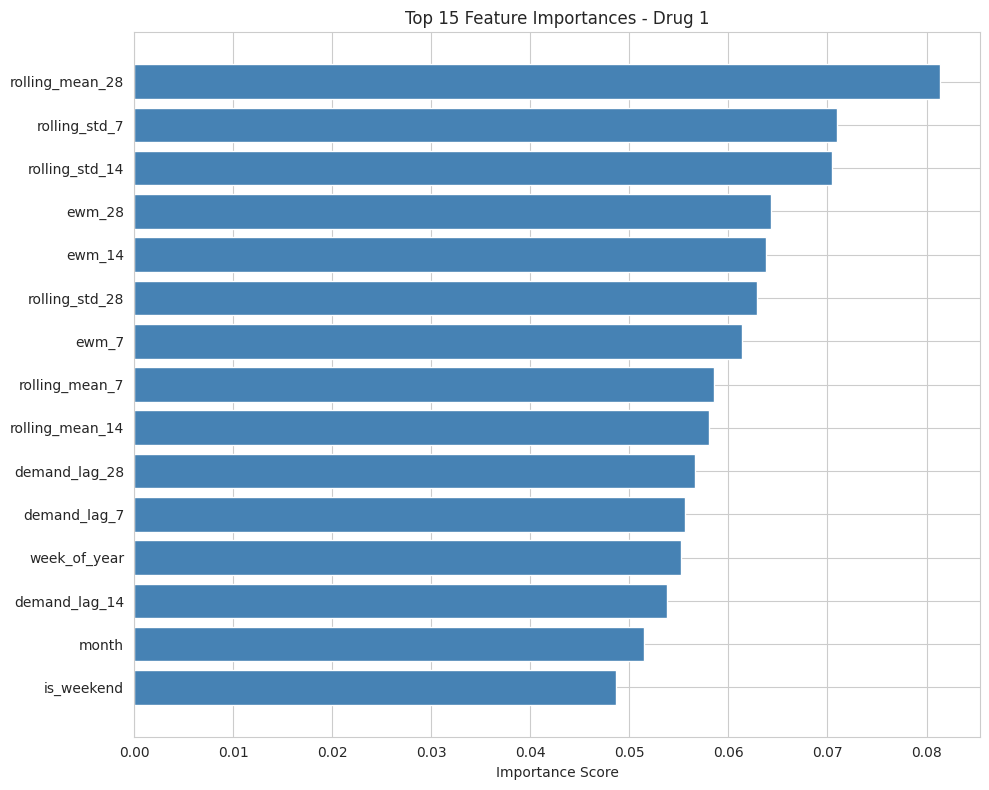


Top 10 Features:
            Feature  Importance
15  rolling_mean_28    0.081330
9     rolling_std_7    0.070914
11   rolling_std_14    0.070419
14           ewm_28    0.064328
13           ewm_14    0.063840
16   rolling_std_28    0.062883
12            ewm_7    0.061418
8    rolling_mean_7    0.058580
10  rolling_mean_14    0.058082
4     demand_lag_28    0.056646


In [71]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': xTrain.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title(f'Top 15 Feature Importances - Drug 1')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10))

In [80]:
def predict(model, xTest):
    """
    Make quantile predictions.
    """

    predictions = model.predict(xTest)

    # Demand / counts should not be negative
    predictions = np.maximum(predictions, 0)

    return predictions

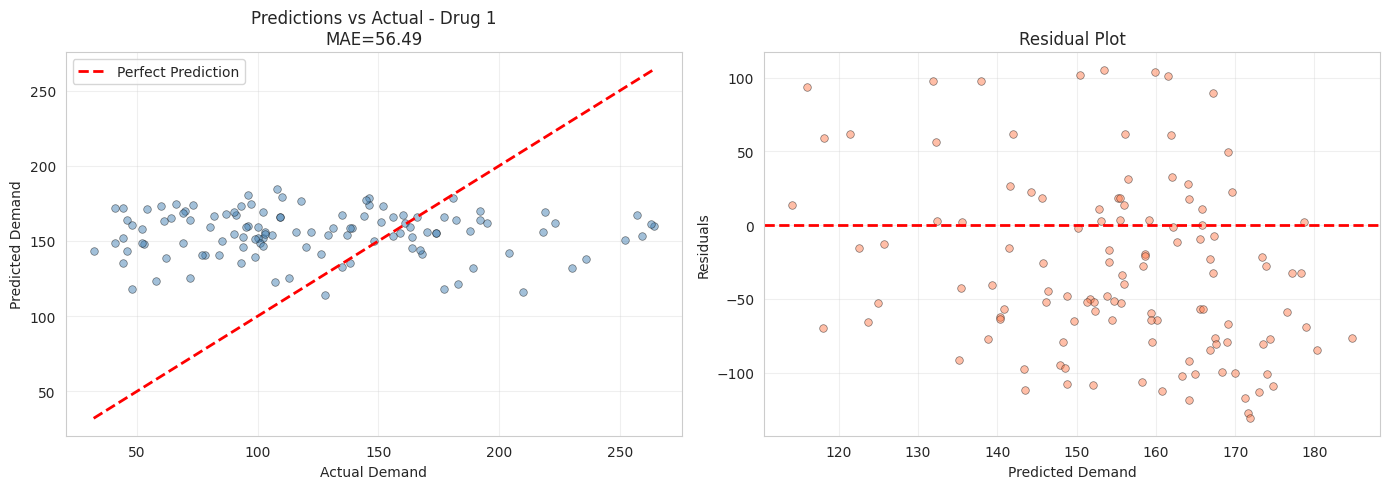

In [79]:
# Plot predictions vs actual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1.scatter(yTest, yPred_test, alpha=0.5, s=30, color='steelblue', edgecolors='black', linewidth=0.5)
ax1.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Demand')
ax1.set_ylabel('Predicted Demand')
ax1.set_title(f'Predictions vs Actual - Drug 1\nMAE={test_mae:.2f}')
ax1.legend()
ax1.grid(alpha=0.3)

# Residual plot
residuals = yTest - yPred_test
ax2.scatter(yPred_test, residuals, alpha=0.5, s=30, color='coral', edgecolors='black', linewidth=0.5)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Demand')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

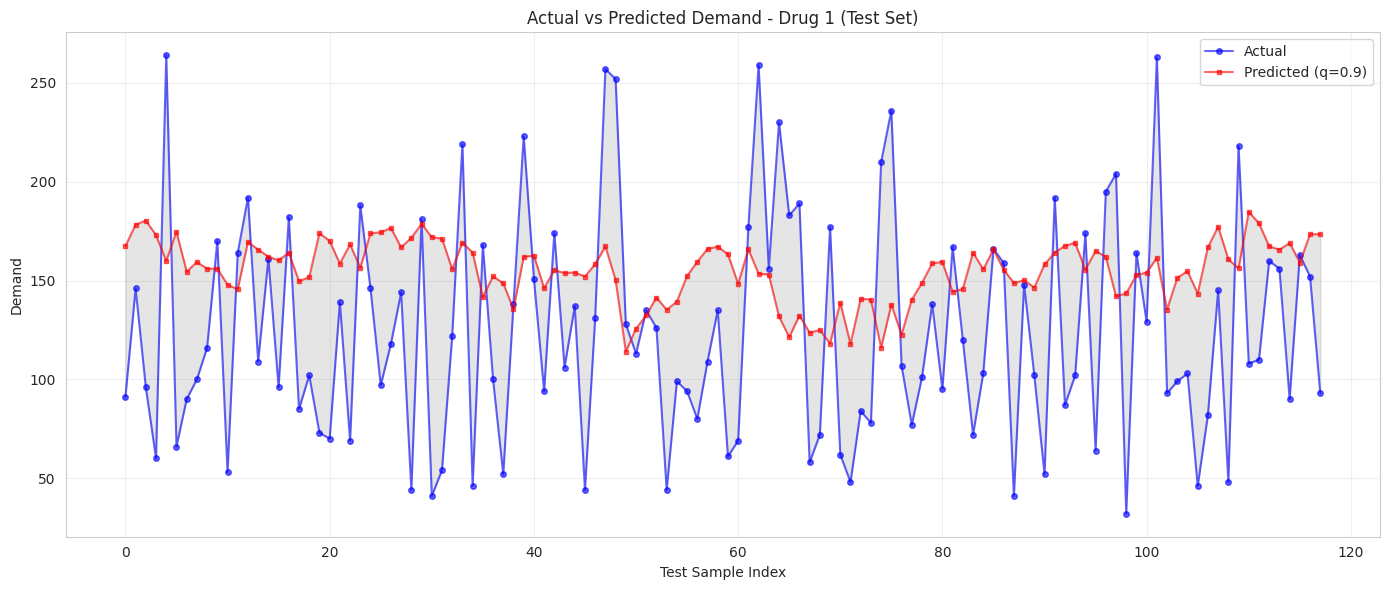

In [76]:
plt.figure(figsize=(14, 6))
test_indices = range(len(yTest))
plt.plot(test_indices, yTest.values, 'o-', label='Actual', color='blue', alpha=0.6, markersize=4)
plt.plot(test_indices, yPred_test, 's-', label=f'Predicted (q={QUANTILE})', color='red', alpha=0.6, markersize=3)
plt.fill_between(test_indices, yTest.values, yPred_test, alpha=0.2, color='gray')
plt.xlabel('Test Sample Index')
plt.ylabel('Demand')
plt.title(f'Actual vs Predicted Demand - Drug 1 (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##**Error Analysis**

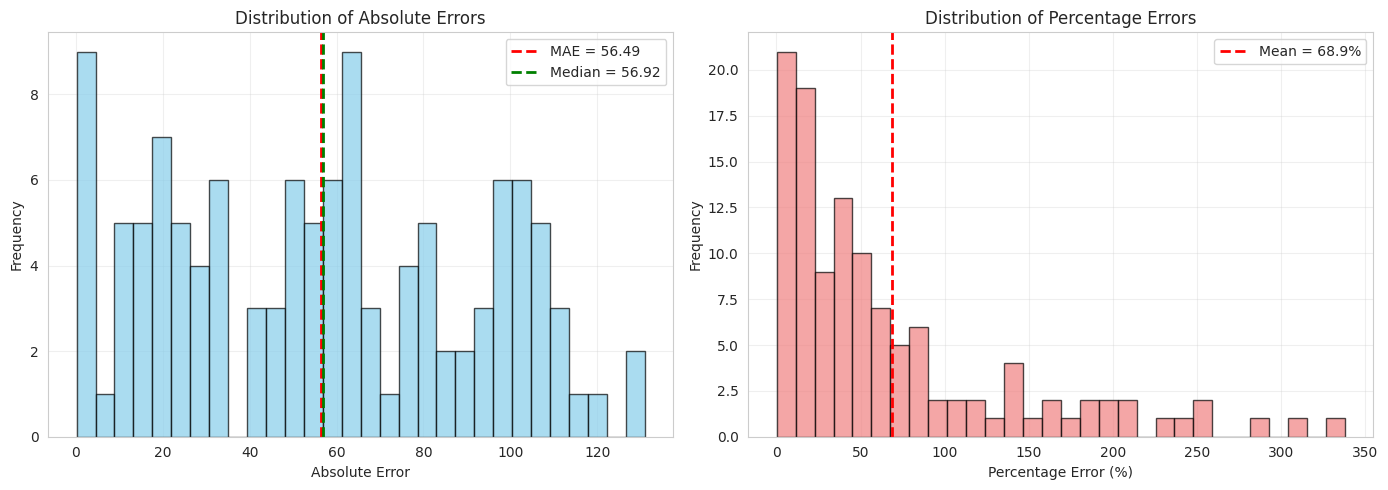

Predictions within 10% error: 13.6%
Predictions within 20% error: 30.5%
Predictions within 30% error: 39.0%


In [81]:
# Error distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute errors
abs_errors = np.abs(residuals)
ax1.hist(abs_errors, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(test_mae, color='red', linestyle='--', lw=2, label=f'MAE = {test_mae:.2f}')
ax1.axvline(np.median(abs_errors), color='green', linestyle='--', lw=2, label=f'Median = {np.median(abs_errors):.2f}')
ax1.set_xlabel('Absolute Error')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Absolute Errors')
ax1.legend()
ax1.grid(alpha=0.3)

# Percentage errors
pct_errors = 100 * abs_errors / (yTest + 1)
ax2.hist(pct_errors, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.axvline(np.mean(pct_errors), color='red', linestyle='--', lw=2, label=f'Mean = {np.mean(pct_errors):.1f}%')
ax2.set_xlabel('Percentage Error (%)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Percentage Errors')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Predictions within 10% error: {(pct_errors < 10).mean():.1%}")
print(f"Predictions within 20% error: {(pct_errors < 20).mean():.1%}")
print(f"Predictions within 30% error: {(pct_errors < 30).mean():.1%}")

##**Summery**

In [83]:
# Summary table
summary = pd.DataFrame({
    'Metric': [
        'Drug',
        'Quantile',
        'Train Samples',
        'Test Samples',
        'Features',
        'Train MAE',
        'Test MAE',
        'Quantile Loss',
        'Coverage',
        'Target Coverage',
        'Within 20% Error'
    ],
    'Value': [
        'Drug 1',
        f'{QUANTILE:.2f}',
        len(xTrain),
        len(xTest),
        len(xTrain.columns),
        f'{train_mae:.2f}',
        f'{test_mae:.2f}',
        f'{test_qloss:.4f}',
        f'{coverage:.2%}',
        f'{QUANTILE:.0%}',
        f'{(pct_errors < 20).mean():.1%}'
    ]
})

print("="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(summary.to_string(index=False))
print("="*70)

FINAL RESULTS SUMMARY
          Metric   Value
            Drug  Drug 1
        Quantile    0.90
   Train Samples     469
    Test Samples     118
        Features      17
       Train MAE   32.36
        Test MAE   56.49
   Quantile Loss 15.8894
        Coverage  69.49%
 Target Coverage     90%
Within 20% Error   30.5%
